In [2]:
# Use sklearn.datasets iris flower dataset to train your model using logistic regression. You need to figure out accuracy of your model and use that to predict different samples in your test dataset. In iris dataset there are 150 samples containing following features,

# Sepal Length
# Sepal Width
# Petal Length
# Petal Width
# Using above 4 features you will clasify a flower in one of the three categories,

# Setosa
# Versicolour
# Virginica

In [4]:
from sklearn import datasets

iris = datasets.load_iris()


In [5]:
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

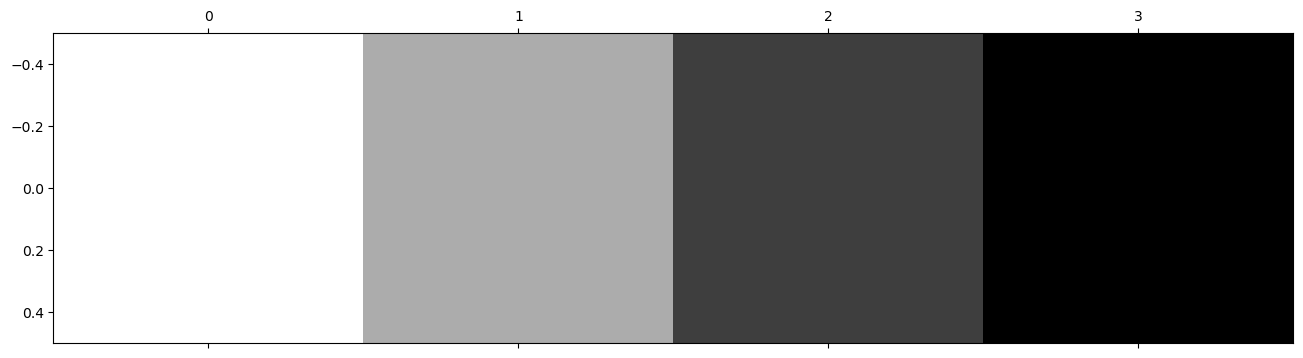

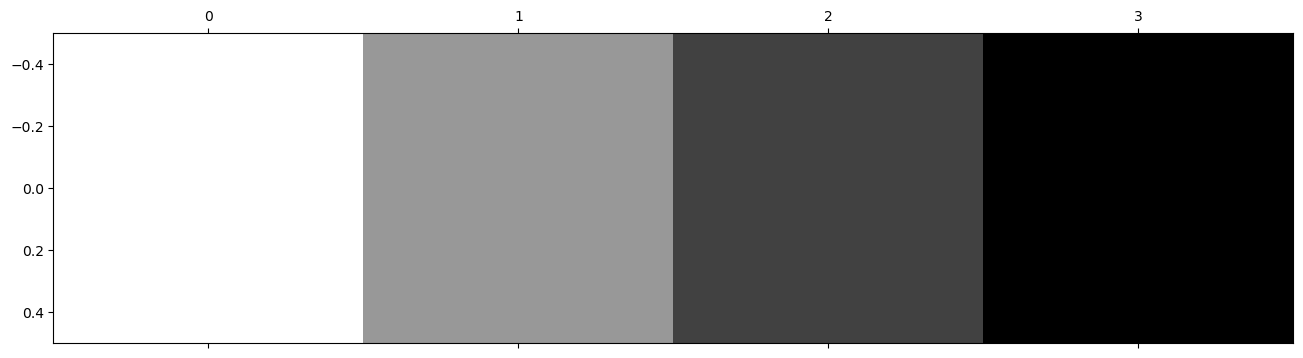

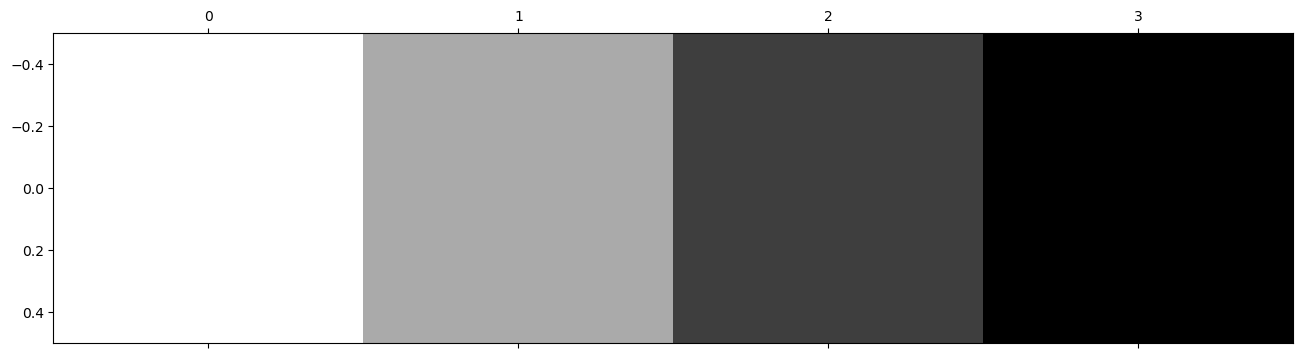

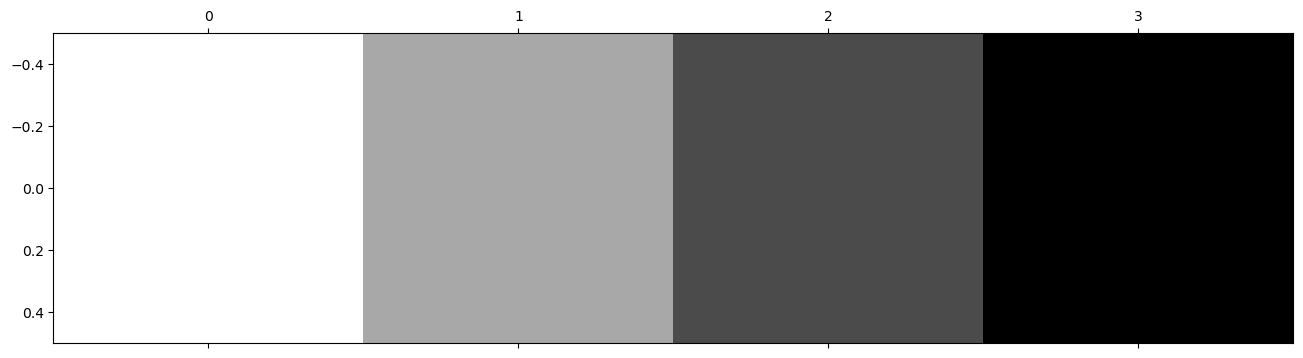

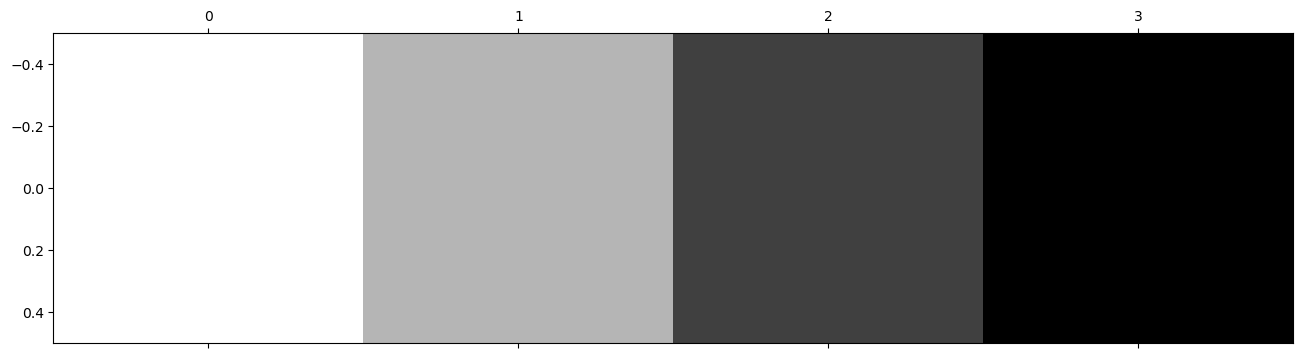

In [33]:
import matplotlib.pyplot as plt
for i in range(5):
    plt.matshow([iris.data[i]])

In [18]:
iris.data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [23]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [29]:
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [31]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [35]:
xtrain,xtest,ytrain,ytest=train_test_split(iris.data,iris.target,test_size=0.2)

In [40]:
model=LogisticRegression(max_iter=1000)

In [41]:
model.fit(xtrain,ytrain)

LogisticRegression(max_iter=1000)

In [42]:
model.predict(xtest)

array([2, 2, 2, 0, 1, 2, 0, 0, 2, 0, 2, 0, 1, 1, 1, 2, 0, 1, 2, 0, 1, 2,
       0, 2, 0, 2, 0, 0, 2, 1])

In [43]:
model.score(xtest,ytest)

0.9666666666666667

In [44]:
from sklearn.metrics import confusion_matrix
ypred=model.predict(xtest)
cm=confusion_matrix(ytest,ypred)
cm

array([[11,  0,  0],
       [ 0,  7,  1],
       [ 0,  0, 11]])

Text(95.72222222222221, 0.5, 'Truth')

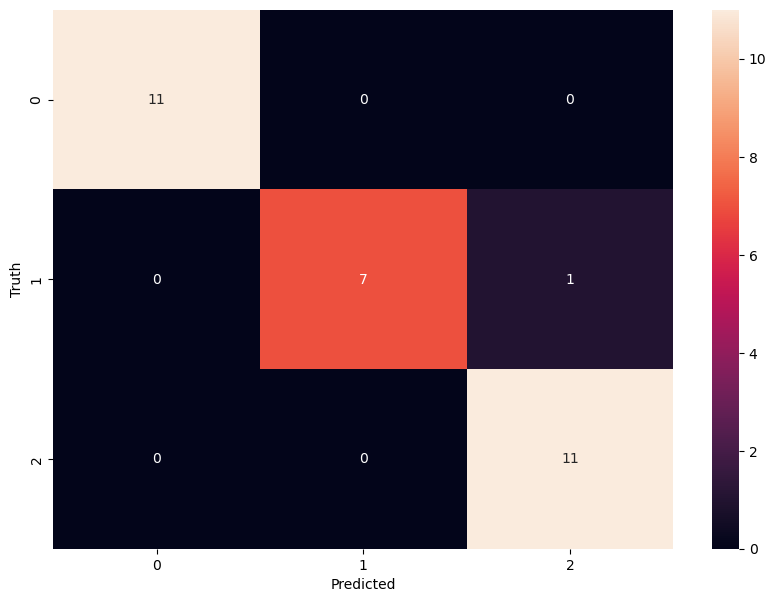

In [46]:
import seaborn as sn
plt.figure(figsize=(10,7))
sn.heatmap(cm,annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [54]:
import pandas as pd

# Create a DataFrame for better readability
df = pd.DataFrame(xtest, columns=iris.feature_names)
df['Predicted Class'] = [iris.target_names[i] for i in ypred]

# Optional: add actual class for comparison
df['Actual Class'] = [iris.target_names[i] for i in ytest]

# Display the result
print(df.head(10))  # You can print more rows if needed

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                6.4               3.1                5.5               1.8   
1                7.2               3.6                6.1               2.5   
2                7.2               3.2                6.0               1.8   
3                5.7               4.4                1.5               0.4   
4                6.6               3.0                4.4               1.4   
5                6.1               3.0                4.9               1.8   
6                5.4               3.4                1.7               0.2   
7                5.3               3.7                1.5               0.2   
8                6.0               2.7                5.1               1.6   
9                5.0               3.4                1.5               0.2   

  Predicted Class Actual Class  
0       virginica    virginica  
1       virginica    virginica  
2       virginica    virginica 